In [1]:
import os
%load_ext autoreload
%autoreload 2

In [2]:
# Cell 1: Imports (Make sure these are at the top of your notebook)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
import gc
import os
import sys

from preprocessing.preprocessing import preprocess_lob_data, split_data_chronological, normalize_features
from preprocessing.dataset import create_sequences, LOBSequenceDataset

from training.trainer import Trainer, Config
from utils.utils import print_model_info

In [3]:
print(os.getcwd())

/Users/janyubhatt/Documents/Learning/Courses/OMSCS/crytpo_DLOB/notebooks


In [4]:
os.chdir('..')  # only need this temporily to get the right paths, change as needed
print(os.getcwd())

/Users/janyubhatt/Documents/Learning/Courses/OMSCS/crytpo_DLOB


In [70]:
import yaml
with open("configs/test_runner.cfg", "r") as f:
    config_dict = yaml.safe_load(f)
config = Config(config_dict)

In [6]:
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [7]:
config.num_files

1

In [8]:
# --- 1. Preprocess Data ---
df_processed = preprocess_lob_data(config)
gc.collect()

Memory Usage: 228.70 MB
Shape before cleaning (dropna): (731123, 81)
NaN count before: 0
Shape after cleaning: (731123, 81)
NaN count after: 0
Calculating alpha dynamically...
Dynamic alpha = 0.000070
Shape after label creation and NaN drop: (731023, 12)
Label distribution:
label
1    0.432018
2    0.284556
0    0.283426
Name: proportion, dtype: float64


0

In [9]:
display(df_processed.shape)
df_processed.head()

(731023, 12)

,b0,b1,a0,a1,bq0,bq1,aq0,aq1,mid_price,spread,vol_imbalance_2,label
50,67828.171875,67826.640625,67828.179688,67830.312500,0.099000,0.041000,0.082174,0.015000,67828.171875,0.007812,0.180569,2
51,67835.062500,67834.437500,67836.000000,67838.031250,0.119232,0.041000,0.022174,0.036852,67835.531250,0.937500,0.461580,2
52,67835.062500,67834.437500,67835.937500,67835.953125,0.117270,0.041000,0.022173,0.150019,67835.500000,0.875000,-0.042129,2
53,67834.437500,67828.187500,67834.453125,67834.468750,0.109949,0.018934,0.430301,0.123337,67834.445312,0.015625,-0.622330,2
54,67828.367188,67828.359375,67832.156250,67833.101562,0.003000,0.010000,0.000856,0.003034,67830.265625,3.789062,0.539332,2


Reduce size just for testing out pipeline even more

In [10]:
print(df_processed.shape)
data_reduction_factor = 10
new_len = int(df_processed.shape[0] / data_reduction_factor)
df_processed = df_processed[0:new_len]
print(df_processed.shape)

(731023, 12)
(73102, 12)


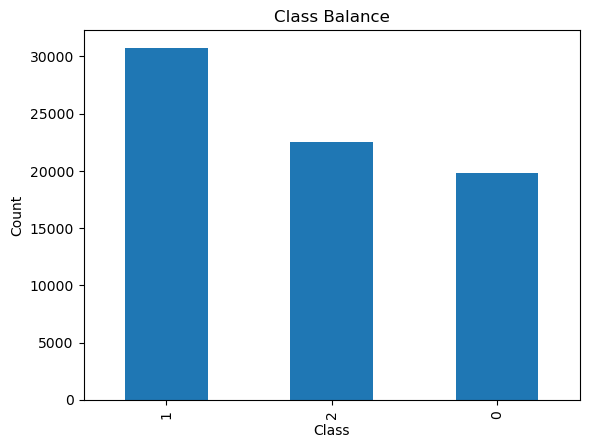

In [11]:
import matplotlib.pyplot as plt
class_counts = df_processed['label'].value_counts()
# Plot
class_counts.plot(kind='bar')
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [12]:
# --- 2. Split Data ---
train_df, val_df, test_df = split_data_chronological(
    df_processed,
    train_frac=config_dict['split_fractions']['train'],
    val_frac=config_dict['split_fractions']['val'],
    test_frac=config_dict['split_fractions']['test']
)
del df_processed
gc.collect()

Data Split: Train=51171, Val=10965, Test=10966


3016

In [13]:
train_df.dtypes.unique(), val_df.dtypes.unique(), test_df.dtypes.unique(),

(array([dtype('float32'), dtype('int64')], dtype=object),
 array([dtype('float32'), dtype('int64')], dtype=object),
 array([dtype('float32'), dtype('int64')], dtype=object))

In [14]:
train_df.head()

,b0,b1,a0,a1,bq0,bq1,aq0,aq1,mid_price,spread,vol_imbalance_2,label
50,67828.171875,67826.640625,67828.179688,67830.312500,0.099000,0.041000,0.082174,0.015000,67828.171875,0.007812,0.180569,2
51,67835.062500,67834.437500,67836.000000,67838.031250,0.119232,0.041000,0.022174,0.036852,67835.531250,0.937500,0.461580,2
52,67835.062500,67834.437500,67835.937500,67835.953125,0.117270,0.041000,0.022173,0.150019,67835.500000,0.875000,-0.042129,2
53,67834.437500,67828.187500,67834.453125,67834.468750,0.109949,0.018934,0.430301,0.123337,67834.445312,0.015625,-0.622330,2
54,67828.367188,67828.359375,67832.156250,67833.101562,0.003000,0.010000,0.000856,0.003034,67830.265625,3.789062,0.539332,2


In [15]:
# --- 3. Normalize Features ---

# Select ONLY numeric feature columns for scaling
# Exclude the 'label' column as well
numeric_cols = train_df.select_dtypes(include=np.number).columns
feature_cols = [col for col in numeric_cols if col != 'label']

# Optional: Print to verify which columns are being scaled
print(f"Columns selected for scaling ({len(feature_cols)}): {feature_cols[:10]}...") # Print first 10

# Check if feature_cols is empty
if not feature_cols:
    raise ValueError("No numerical feature columns found for scaling after excluding 'label'.")

# Call normalize_features with the correctly filtered list
train_df_norm, val_df_norm, test_df_norm, scaler = normalize_features(
    train_df, val_df, test_df, feature_cols
)
train_df_norm.loc[:, "label"] = train_df.loc[:, "label"].copy()
val_df_norm.loc[:, "label"] = val_df.loc[:, "label"].copy()
test_df_norm.loc[:, "label"] = test_df.loc[:, "label"].copy()
del train_df, val_df, test_df
gc.collect()


Columns selected for scaling (11): ['b0', 'b1', 'a0', 'a1', 'bq0', 'bq1', 'aq0', 'aq1', 'mid_price', 'spread']...
Normalization applied.


0

In [16]:
train_df_norm.head()

,b0,b1,a0,a1,bq0,bq1,aq0,aq1,mid_price,spread,vol_imbalance_2,label
50,-0.744021,-0.744949,-0.762622,-0.756460,0.056554,0.004191,-0.083228,-0.033205,-0.753402,-0.855443,0.151442,2
51,-0.686129,-0.679466,-0.696953,-0.691633,0.128201,0.004191,-0.089565,-0.027988,-0.691584,-0.503492,0.550971,2
52,-0.686129,-0.679466,-0.697478,-0.709086,0.121250,0.004191,-0.089565,-0.000975,-0.691846,-0.527152,-0.165182,2
53,-0.691380,-0.731957,-0.709942,-0.721553,0.095328,-0.184894,-0.046461,-0.007344,-0.700706,-0.852486,-0.990085,2
54,-0.742380,-0.730514,-0.729230,-0.733036,-0.283403,-0.261456,-0.091817,-0.036061,-0.735815,0.576024,0.661516,2


In [17]:
config.sequence_length = 1

In [18]:
if config.precision == 'float16' or None:
    precision = np.float16
elif config.precision == 'float32':
    precision = np.float32
elif config.precision == 'float64':
    precision = np.float64

print(f"Precision is: {precision}")

Precision is: <class 'numpy.float32'>


In [19]:
# --- 4. Create Sequences ---
# Separate features and labels before sequencing
y_train_series = train_df_norm.pop('label').values
X_train_features = train_df_norm[feature_cols].astype(np.float32).values

y_val_series = val_df_norm.pop('label').values
X_val_features = val_df_norm[feature_cols].astype(np.float32).values

y_test_series = test_df_norm.pop('label').values
X_test_features = test_df_norm[feature_cols].astype(np.float32).values

T = config.sequence_length
X_train_seq, y_train_seq = create_sequences(X_train_features, y_train_series, T, precision=np.float32)
X_val_seq, y_val_seq = create_sequences(X_val_features, y_val_series, T, precision=np.float32)
X_test_seq, y_test_seq = create_sequences(X_test_features, y_test_series, T, precision=np.float32)

print("\nSequence Creation Complete:")
print(f"X_train_seq shape: {X_train_seq.shape}, y_train_seq shape: {y_train_seq.shape}")
print(f"X_val_seq shape: {X_val_seq.shape}, y_val_seq shape: {y_val_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}, y_test_seq shape: {y_test_seq.shape}")

del train_df_norm, val_df_norm, test_df_norm # Free memory
del X_train_features, y_train_series, X_val_features, y_val_series, X_test_features, y_test_series
gc.collect()


Sequence Creation Complete:
X_train_seq shape: (51170, 1, 11), y_train_seq shape: (51170,)
X_val_seq shape: (10964, 1, 11), y_val_seq shape: (10964,)
X_test_seq shape: (10965, 1, 11), y_test_seq shape: (10965,)


0

In [20]:
# --- 5. Create Datasets & DataLoaders ---
train_dataset = LOBSequenceDataset(X_train_seq, y_train_seq, device=device)
val_dataset = LOBSequenceDataset(X_val_seq, y_val_seq, device=device)
test_dataset = LOBSequenceDataset(X_test_seq, y_test_seq, device=device)

#train_loader = DataLoader(train_dataset, batch_size=config.train.batch_size, shuffle=True) # num_workers/pin_memory optional
#val_loader = DataLoader(val_dataset, batch_size=config.train.batch_size, shuffle=False)
#test_loader = DataLoader(test_dataset, batch_size=config.train.batch_size, shuffle=False)
# gc.collect()

In [21]:
config.model.in_features = config.num_levels_features * 4 + 3

In [22]:
trainer = Trainer(config, train_dataset, val_dataset, test_dataset, device)

One batch shape: torch.Size([1024, 11, 1])

Datasets and DataLoaders created.
Number of training batches: 50
Number of validation batches: 11
Number of testing batches: 11
Input Size: (1, 11)
Model: Basic MLP Model

📋 Model Summary:

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
BasicMLPModel                            [1, 11]                   [1, 3]                    36                        --
├─Linear: 1-1                            [1, 11]                   [1, 3]                    36                        --
├─ReLU: 1-2                              [1, 3]                    [1, 3]                    --                        --
Total params: 72
Trainable params: 72
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


In [23]:
trainer.device

'mps'

In [59]:
from experiment_runner.experiment_runner import run_single_trial, run_parameter_sweep, orchestrate_experiment
from experiment_runner.experiment_runner import save_df

In [39]:
base_dir = 'results/test/'
trial_name = 'test_single_trial_method'
trainer, training_history, final_results = run_single_trial(trial_config=config,
                           train_dataset=train_dataset,
                           val_dataset=val_dataset,
                           test_dataset=test_dataset,
                           device=device,
                           base_dir=base_dir,
                           trial_name=trial_name,
                           verbose=True)

Created experiment directory: results/test/test_single_trial_method

--- Running Trial: test_single_trial_method ---
Config: {'data_path': 'data/coinbase_book_2024-10-29_2024-11-11', 'num_files': 1, 'precision': 'float32', 'clean_strategy': 'dropna', 'num_levels_features': 2, 'label_price_type': 'simple_midpoint', 'label_price_levels': 1, 'label_price_col': None, 'label_method': 'tlob', 'label_k': 50, 'label_h': 50, 'label_alpha': 'auto', 'verbose': True, 'sequence_length': 1, 'output_path': None, 'split_fractions': <training.trainer.Config object at 0x17befe630>, 'seed': 42, 'train': <training.trainer.Config object at 0x17c3a3800>, 'model': <training.trainer.Config object at 0x17c527b30>, 'optimizer': <training.trainer.Config object at 0x17c44efc0>}
Configuration saved to results/test/test_single_trial_method/trial_config.yaml
One batch shape: torch.Size([1024, 11, 1])

Datasets and DataLoaders created.
Number of training batches: 50
Number of validation batches: 11
Number of testing 

Try sweeping

In [57]:
sweep_dir = 'results/test_sweep_function'
sweep_param_name='train.lr'
sweep_values=[0.01, 0.001,]
results_df, best_config_dict = run_parameter_sweep(
                                base_config= config,
                                sweep_param_name=sweep_param_name,
                                sweep_values =sweep_values,
                                train_dataset=train_dataset,
                                val_dataset=val_dataset,
                                test_dataset=test_dataset,
                                device=device,
                                sweep_dir=sweep_dir,
                                save_trial_models=True,
                                verbose=True
                                )



===== Running Sweep for Parameter: train.lr =====
Created experiment directory: results/test_sweep_function/trial_00_lr_0.01

--- Running Trial: trial_00_lr_0.01 ---
Config: {'data_path': 'data/coinbase_book_2024-10-29_2024-11-11', 'num_files': 1, 'precision': 'float32', 'clean_strategy': 'dropna', 'num_levels_features': 2, 'label_price_type': 'simple_midpoint', 'label_price_levels': 1, 'label_price_col': None, 'label_method': 'tlob', 'label_k': 50, 'label_h': 50, 'label_alpha': 'auto', 'verbose': True, 'sequence_length': 1, 'output_path': None, 'split_fractions': <training.trainer.Config object at 0x189ee5490>, 'seed': 42, 'train': <training.trainer.Config object at 0x189f23c50>, 'model': <training.trainer.Config object at 0x189f23d70>, 'optimizer': <training.trainer.Config object at 0x1893a2660>}
Configuration saved to results/test_sweep_function/trial_00_lr_0.01/trial_config.yaml
One batch shape: torch.Size([1024, 11, 1])

Datasets and DataLoaders created.
Number of training batche

Run full experiment

In [74]:
experiment_name = 'test_experiment'
sweeps_to_run = {
    'train.lr': [0.01, 0.001],
    'batch_size': [1024, 2048]
}
orchestrate_experiment(
    experiment_name=experiment_name,
    train_dataset=train_dataset,
    val_dataset=train_dataset,
    test_dataset=test_dataset, 
    base_config=config,
    sweeps_to_run=sweeps_to_run, 
    base_results_dir="results",
    device_str="auto",
    save_models_in_sweep=True,
    save_final_model=True,
)


Using device: mps
Created experiment directory: results/test_experiment_20250426_110933
Starting hyperparameter sweeps...

======= Starting Multiple Sweeps in: results/test_experiment_20250426_110933 =======

===== Running Sweep for Parameter: train.lr =====
Created experiment directory: results/test_experiment_20250426_110933/sweep_train_lr/trial_00_lr_0.01

--- Running Trial: trial_00_lr_0.01 ---
Config: {'data_path': 'data/coinbase_book_2024-10-29_2024-11-11', 'output_path': None, 'output_name': 'some_descriptive_name', 'num_files': 1, 'precision': 'float32', 'clean_strategy': 'dropna', 'num_levels_features': 2, 'label_price_type': 'simple_midpoint', 'label_price_levels': 1, 'label_price_col': None, 'label_method': 'tlob', 'label_k': 50, 'label_h': 50, 'label_alpha': 'auto', 'verbose': True, 'sequence_length': 1, 'split_fractions': <training.trainer.Config object at 0x18908e180>, 'seed': 42, 'train': <training.trainer.Config object at 0x189fbec90>, 'model': <training.trainer.Config 

/Users/janyubhatt/opt/anaconda3/envs/cs7643-a2/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch[Batch]: [1][0/50]	Avg_Loss 1.137 (1.137)	 Time 0.020 (0.020)	
Epoch[Batch]: [1][5/50]	Avg_Loss 1.098 (1.108)	 Time 0.011 (0.012)	
Epoch[Batch]: [1][10/50]	Avg_Loss 1.083 (1.100)	 Time 0.012 (0.012)	
Epoch[Batch]: [1][15/50]	Avg_Loss 1.087 (1.096)	 Time 0.012 (0.012)	
Epoch[Batch]: [1][20/50]	Avg_Loss 1.076 (1.094)	 Time 0.075 (0.015)	
Epoch[Batch]: [1][25/50]	Avg_Loss 1.078 (1.091)	 Time 0.010 (0.014)	
Epoch[Batch]: [1][30/50]	Avg_Loss 1.094 (1.089)	 Time 0.010 (0.015)	
Epoch[Batch]: [1][35/50]	Avg_Loss 1.105 (1.089)	 Time 0.011 (0.014)	
Epoch[Batch]: [1][40/50]	Avg_Loss 1.074 (1.088)	 Time 0.010 (0.014)	
Epoch[Batch]: [1][45/50]	Avg_Loss 1.077 (1.087)	 Time 0.011 (0.013)	
Epoch 1/2 — Train loss: 1.0862 — Train F₁: 0.3696
  ↳ Val loss: 1.0759 — Val F₁: 0.3934
Epoch finished in 55.27923295786604 seconds
  ↳ New best model (val_loss=1.0759), checkpoint saved.
Epoch[Batch]: [2][0/50]	Avg_Loss 1.069 (1.086)	 Time 0.011 (0.013)	
Epoch[Batch]: [2][5/50]	Avg_Loss 1.078 (1.085)	 Time 0.0